#  IF3270 Machine Learning | Tubes 1

# ~ Kelompok ~
Anggota : 
1. 13523128 Ivant Samuel Silaban
2. 13523133 Rafa Abdussalam Danadyaksa
3. 13523164 Muhammad Rizain Firdaus

# Setup & Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path as path

root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.model.layers import FFNN, Linear
from src.model.activations import Activation
from src.model.loss import Loss
from src.model.optimizer import GradientDescent
from src.model.initializer import Initializer
from src.utils.data_loader import DataLoader
from src.utils.visualization import Visualizer

print('Setup selesai!')

Setup selesai!


## Load Data

In [2]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim : {INPUT_DIM}')
print(f'Train     : {X_train.shape}')
print(f'Val       : {X_val.shape}')
print(f'Test      : {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 9

None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim : 21
Train     : (6400, 21)
Val       : (1600, 21)
Test      : (2000, 21)


## FFNN Model

In [3]:
model = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = [128, 64],
    output_dim        = 1,
    hidden_activation = 'relu',
    output_activation = 'sigmoid',
    loss_name         = 'bce',
    init_method       = 'he',
    seed              = 42,
)

optimizer = GradientDescent(lr=0.01)

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42


## Latih Model

In [4]:
EPOCHS     = 50
BATCH_SIZE = 32
LR         = 0.01

optimizer = GradientDescent(lr=LR)

for epoch in range(1, EPOCHS + 1):
    metrics = model.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/50  |  train_loss: 0.6050  |  val_loss: 0.5353  |  val_acc: 0.7425
Epoch   2/50  |  train_loss: 0.5276  |  val_loss: 0.4999  |  val_acc: 0.7544
Epoch   3/50  |  train_loss: 0.5083  |  val_loss: 0.4894  |  val_acc: 0.7538
Epoch   4/50  |  train_loss: 0.5017  |  val_loss: 0.4836  |  val_acc: 0.7612
Epoch   5/50  |  train_loss: 0.4979  |  val_loss: 0.4814  |  val_acc: 0.7625
Epoch   6/50  |  train_loss: 0.4951  |  val_loss: 0.4802  |  val_acc: 0.7662
Epoch   7/50  |  train_loss: 0.4930  |  val_loss: 0.4815  |  val_acc: 0.7719
Epoch   8/50  |  train_loss: 0.4916  |  val_loss: 0.4796  |  val_acc: 0.7675
Epoch   9/50  |  train_loss: 0.4899  |  val_loss: 0.4786  |  val_acc: 0.7650
Epoch  10/50  |  train_loss: 0.4885  |  val_loss: 0.4786  |  val_acc: 0.7681
Epoch  11/50  |  train_loss: 0.4876  |  val_loss: 0.4779  |  val_acc: 0.7581
Epoch  12/50  |  train_loss: 0.4864  |  val_loss: 0.4788  |  val_acc: 0.7669
Epoch  13/50  |  train_loss: 0.4854  |  val_loss: 0.4774  |  val_acc: 0.7644

## Visualisasi

### 1. Plot Traning History

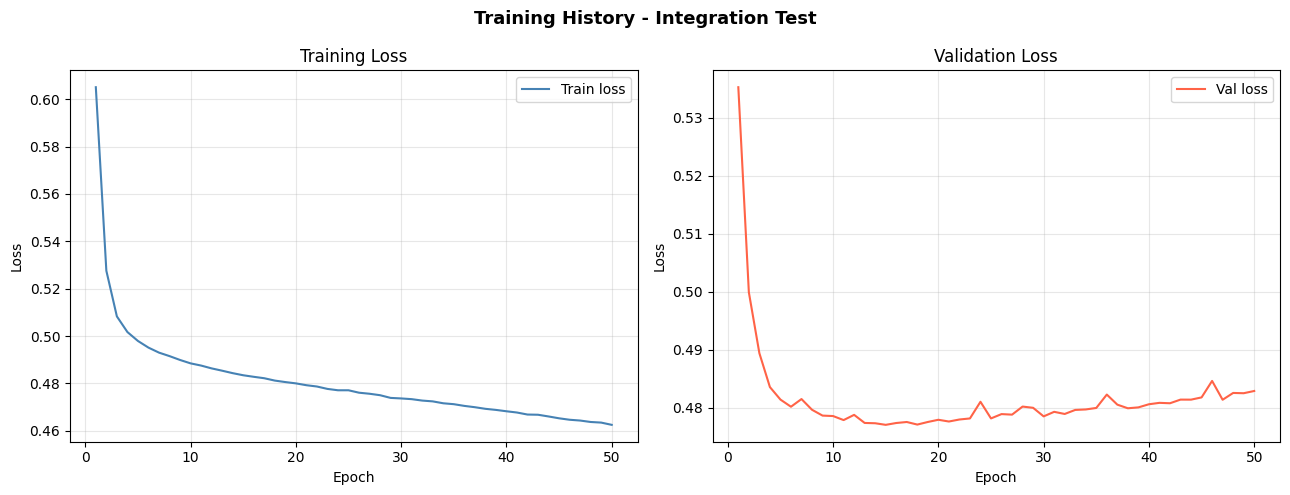

In [5]:
viz = Visualizer()
history = model.get_training_history()
viz.plot_loss_curve(history, title='Training History - Integration Test')

### 2. Plot Weight Distribution

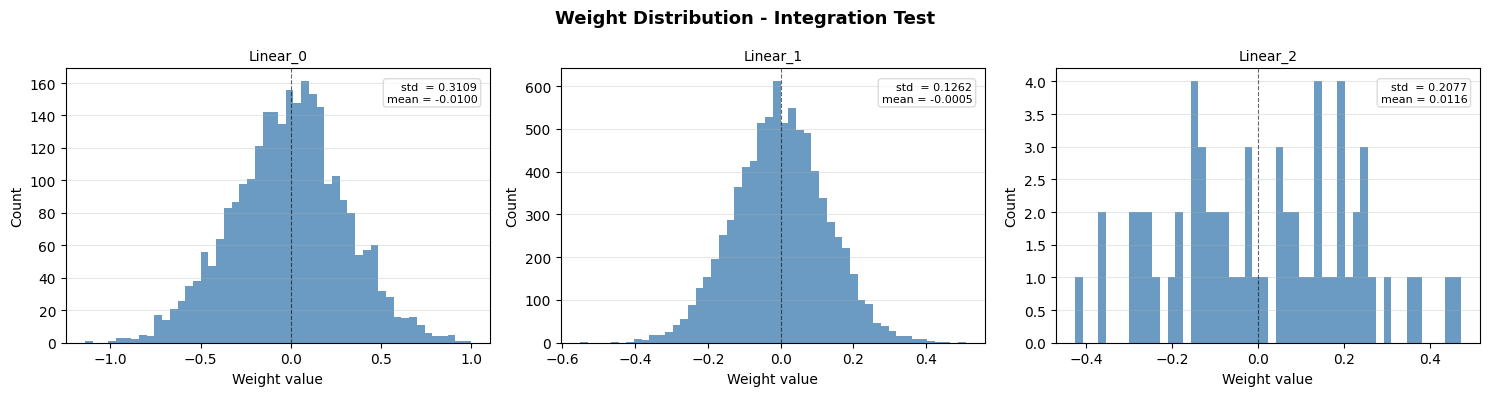

In [6]:
weights = model.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution - Integration Test'
)

### 3. Plot Gradient Distribution

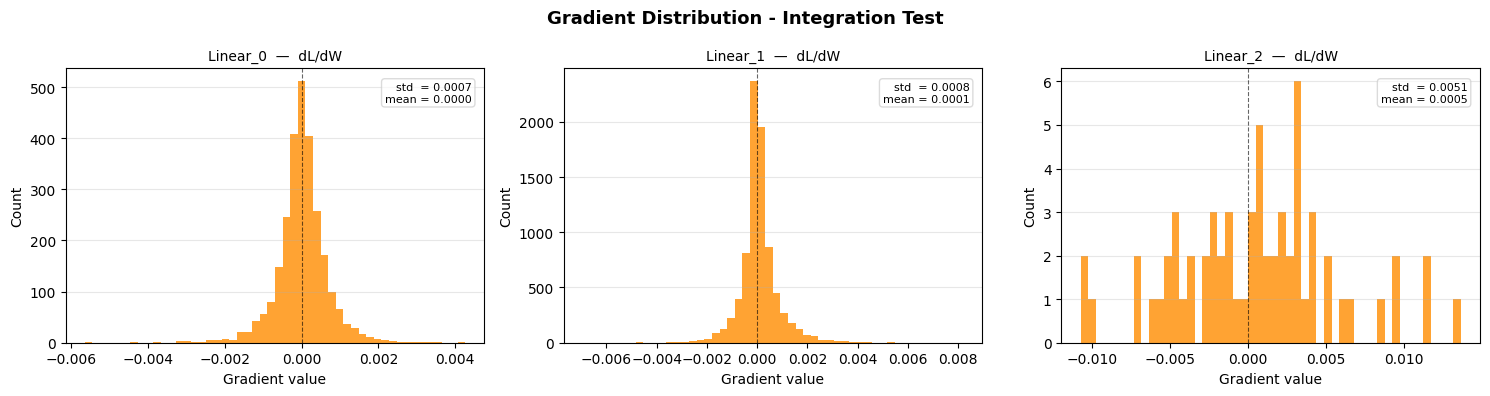

In [7]:
y_pred_viz = model.forward(X_test)
model.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution - Integration Test'
)

## Prediction 

In [8]:
y_pred  = model.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7360


## Save Model

In [9]:
model.save('../results/test_SaveLoad')

[FFNN] Model tersimpan di '../results/test_SaveLoad.npz' dan '../results/test_SaveLoad.json'


## Verifikasi Load Model

In [11]:
model_loaded = FFNN.load('../results/test_SaveLoad')

# 3. Bandingkan prediksi — harus identik
y_pred_original = model.predict(X_test)
y_pred_loaded   = model_loaded.predict(X_test)

print("\nPrediksi sama:", np.all(y_pred_original == y_pred_loaded))
print("Accuracy original:", float(np.mean(y_pred_original == y_test.ravel())))
print("Accuracy loaded  :", float(np.mean(y_pred_loaded   == y_test.ravel())))

import json
with open('../results/test_SaveLoad.json') as f:
    config = json.load(f)
print("\nConfig tersimpan:")
print(config)

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he
[FFNN] Model berhasil di-load dari '../results/test_SaveLoad'

Prediksi sama: True
Accuracy original: 0.736
Accuracy loaded  : 0.736

Config tersimpan:
{'input_dim': 21, 'hidden_dim': [128, 64], 'output_dim': 1, 'hidden_activation': 'relu', 'output_activation': 'sigmoid', 'loss_name': 'bce', 'init_method': 'he'}
